

# Training E. coli adage models for GLEAn

#### Georgia Doing, <doingg@union.edu>

#### May 11, 2026

This notebook trains adage models on E. coli a couple datasets with 
various hyperparameter choices in order to visualize training dynamics
on training and validation loss as well and hidden layer weight
distributions. 

#### Outline

1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data
3. Train some models with hyperparameters from previous search
4. Plot training loss over epochs
5. Plot weight distributions of final models



### 1. Loading classes, modules

In [1]:
# for adage models
from adage import Adage as ad
from adage import SeqAdage

# for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# misc
#from scipy.stats import hypergeom
#import csv
#import random
import time
import tensorflow as tf


2026-07-28 20:46:36.569897: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-28 20:46:36.597065: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
False


## 2. Plotting training data distributions

Here we are looking at two training datasets. The first only has genes
in MG1655 and the second has genes in either MG1655 or a couple isolates
of interest (to include eloD genes).

### MG1655 genes

This compendium only has genes in MG1655 and samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

In [3]:
all_comp = pd.read_csv('../data_files/ecmg_lcn01.csv', index_col = 0) 
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [4]:
print("There are {} genes (features) and {} samples".format(gene_num,
                                                            samp_num))

There are 4272 genes (features) and 16150 samples


In [5]:
all_comp.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644788.salmon,...,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon,SRX28568289.salmon
11997cc26382b2c286cd502685a104a5_13,0.234579,0.254150,0.243907,0.243012,0.235899,0.280912,0.264422,0.270019,0.317142,0.299569,...,0.298677,0.276767,0.351828,0.337247,0.312398,0.321875,0.321036,0.318821,0.311354,0.304692
11997cc26382b2c286cd502685a104a5_45,0.272709,0.262344,0.276821,0.249772,0.268399,0.265376,0.257609,0.264961,0.292222,0.299569,...,0.299682,0.305974,0.262008,0.261497,0.286625,0.293051,0.290033,0.296570,0.277161,0.276499
11997cc26382b2c286cd502685a104a5_102,0.037627,0.026616,0.025180,0.039842,0.027814,0.049805,0.019763,0.050739,0.144859,0.160183,...,0.278582,0.273690,0.302600,0.296838,0.335073,0.335004,0.331882,0.327804,0.308324,0.290361
11997cc26382b2c286cd502685a104a5_110,0.323079,0.320358,0.293970,0.311448,0.291142,0.281595,0.328269,0.314841,0.311958,0.305564,...,0.342191,0.338557,0.351999,0.363475,0.374065,0.357845,0.361081,0.365622,0.347532,0.342460
11997cc26382b2c286cd502685a104a5_72,0.305784,0.336823,0.276244,0.339746,0.291997,0.300844,0.333681,0.289742,0.420649,0.399211,...,0.490506,0.479772,0.329882,0.318733,0.428194,0.428926,0.428631,0.431648,0.540901,0.509258


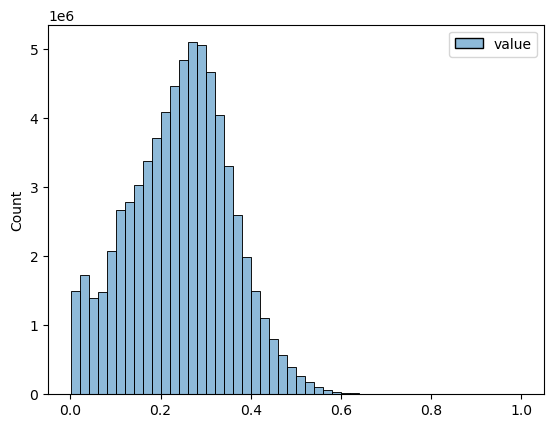

In [6]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

### MG1655+ genes

This compendium has genes in MG1655 or a couple other strains/isoaltes 
and samples have been filtered by sparsity and housekeeping gene 
expression, but are expected to be more sparse given the presence of 
strain-specific accessory genes.

The data has been log transformed and scaled to be between 0 and 1.

In [7]:
all_comp = pd.read_csv('../data_files/ecmgp_lcn01.csv', index_col = 0) 
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [8]:
print("There are {} genes (features) and {} samples".format(gene_num,
                                                            samp_num))

There are 6390 genes (features) and 16122 samples


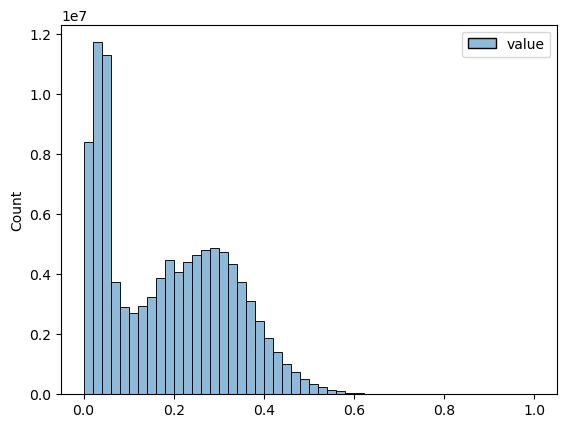

In [9]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

## 3. Tuners to select hyperparameters

By default, the tuner method searches the following:

* enccoding dimension: 10 - 100, by 10
* L1 normalizaion: 0 - 0.15, by 0.005
* L2 normalization: 0 - 0.9, by 0.05
* activation functios: "sigmoid","tanh","relu", "celu"
* tied: True
* epochs: 100
* initialization: "glorot_uniform","glorot_normal"
* batch_size: 5 - 100, by 5
* dropout: 0 - 0.9, by 0.1
* momentum: 0 - 0.9, by 0.1
* learning rate: 0.001 - 0.1, by 0.01

In [10]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv"]
model_dict_tune = {}
model_dict_best = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/' + comp,
                                                  seed=seed+100) 
        mseq, t = sa.tune_model(seed+100)
        #temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_tune[name] = t
        model_dict_best[name] = mseq
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

Trial 90 Complete [00h 00m 12s]
val_loss: 0.057494644075632095

Best val_loss So Far: 0.0030967954080551863
Total elapsed time: 00h 09m 01s
Results summary
Results in /work/gd134/hyperband_search_dir/ecmg_mgs_lcn01_102
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0082 summary
Hyperparameters:
units: 10
dropout: 0.5
act1: relu
act2: tanh
shuffle: True
init: glorot_normal
kl1: 0.11
kl2: 0.1
lr: 0.081
bs: 60
mm: 0.4
tied: 1
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0081
Score: 0.0030967954080551863

Trial 0081 summary
Hyperparameters:
units: 10
dropout: 0.5
act1: relu
act2: tanh
shuffle: True
init: glorot_normal
kl1: 0.11
kl2: 0.1
lr: 0.081
bs: 60
mm: 0.4
tied: 1
tuner/epochs: 17
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.003098471090197563

Trial 0072 summary
Hyperparameters:
units: 10
dropout: 0.5
act1: sigmoid
act2: celu
shuffle: True
init: glorot_uniform
kl1: 0.1
kl2: 0.05
lr: 0.061
bs: 75

In [22]:
HP_list = []

for t in list(model_dict_tune.keys()):
    sp = t[:-4]
    seed = t[-3:]
    trialsSE = model_dict_tune[t].oracle.get_best_trials(num_trials=100)
    i = 0
    for trial in trialsSE:
        HP_list.append(trial.hyperparameters.get_config()["values"] | 
                       {"Score": trial.score}| 
                       {"Trial ID": trial.trial_id} | 
                       {"Best step": trial.best_step} | 
                       {"tuner_key" : t} | 
                       {"species" : sp} | 
                       {"seed" : seed} | 
                       {"rank" : i})
        i+=1

tuners_df = pd.DataFrame(HP_list)

tuners_df["tied_bool"] = tuners_df["tied"].astype("bool")

tuners_df.T

,0,1,2,3,4,5,6,7,8,9,...,260,261,262,263,264,265,266,267,268,269
units,30,10,10,10,10,10,30,30,30,50,...,20,40,10,90,80,20,80,10,50,20
dropout,0.8,0.3,0.3,0.5,0.5,0.5,0.8,0.8,0.8,0.6,...,0.0,0.3,0.6,0.5,0.5,0.8,0.0,0.2,0.0,0.3
act1,sigmoid,relu,relu,tanh,tanh,tanh,sigmoid,sigmoid,sigmoid,relu,...,celu,sigmoid,tanh,relu,sigmoid,relu,relu,celu,celu,celu
act2,tanh,tanh,tanh,celu,celu,celu,tanh,tanh,tanh,celu,...,tanh,tanh,celu,tanh,tanh,celu,celu,celu,celu,celu
shuffle,False,False,False,False,False,False,False,False,False,True,...,False,True,True,True,True,False,True,False,False,False
init,glorot_uniform,glorot_normal,glorot_normal,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,glorot_uniform,...,glorot_uniform,glorot_normal,glorot_normal,glorot_normal,glorot_normal,glorot_uniform,glorot_normal,glorot_uniform,glorot_uniform,glorot_uniform
kl1,0.08,0.145,0.145,0.14,0.14,0.14,0.08,0.08,0.08,0.065,...,0.115,0.135,0.065,0.03,0.015,0.01,0.105,0.035,0.14,0.05
kl2,0.75,0.65,0.65,0.7,0.7,0.7,0.75,0.75,0.75,0.5,...,0.65,0.15,0.45,0.85,0.45,0.0,0.1,0.3,0.3,0.05
lr,0.061,0.091,0.091,0.031,0.031,0.031,0.061,0.061,0.061,0.071,...,0.051,0.031,0.011,0.021,0.041,0.011,0.001,0.011,0.001,0.001
bs,10,90,90,5,5,5,10,10,10,15,...,80,100,70,25,60,80,75,70,80,100


(array([109.,  13.,  14.,  45.,   2.,   0.,   1.,   0.,   1.,  85.]),
 array([2.51479155, 2.84639484, 3.17799814, 3.50960144, 3.84120474,
        4.17280804, 4.50441134, 4.83601464, 5.16761794, 5.49922124,
        5.83082454]),
 <BarContainer object of 10 artists>)

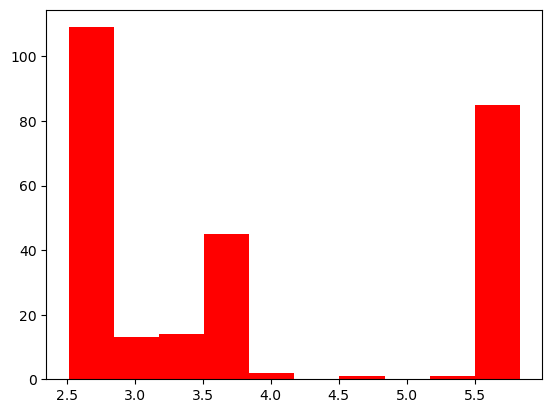

In [16]:
tuners_df['seed_cat'] = tuners_df["seed"].astype('category')
tuners_df['nlogScore'] = np.negative(np.log(tuners_df["Score"]))
plt.hist(tuners_df["nlogScore"][tuners_df["species"] == "ad_ecmg_mgs_lcn01_2025_09_01"], color = "red")


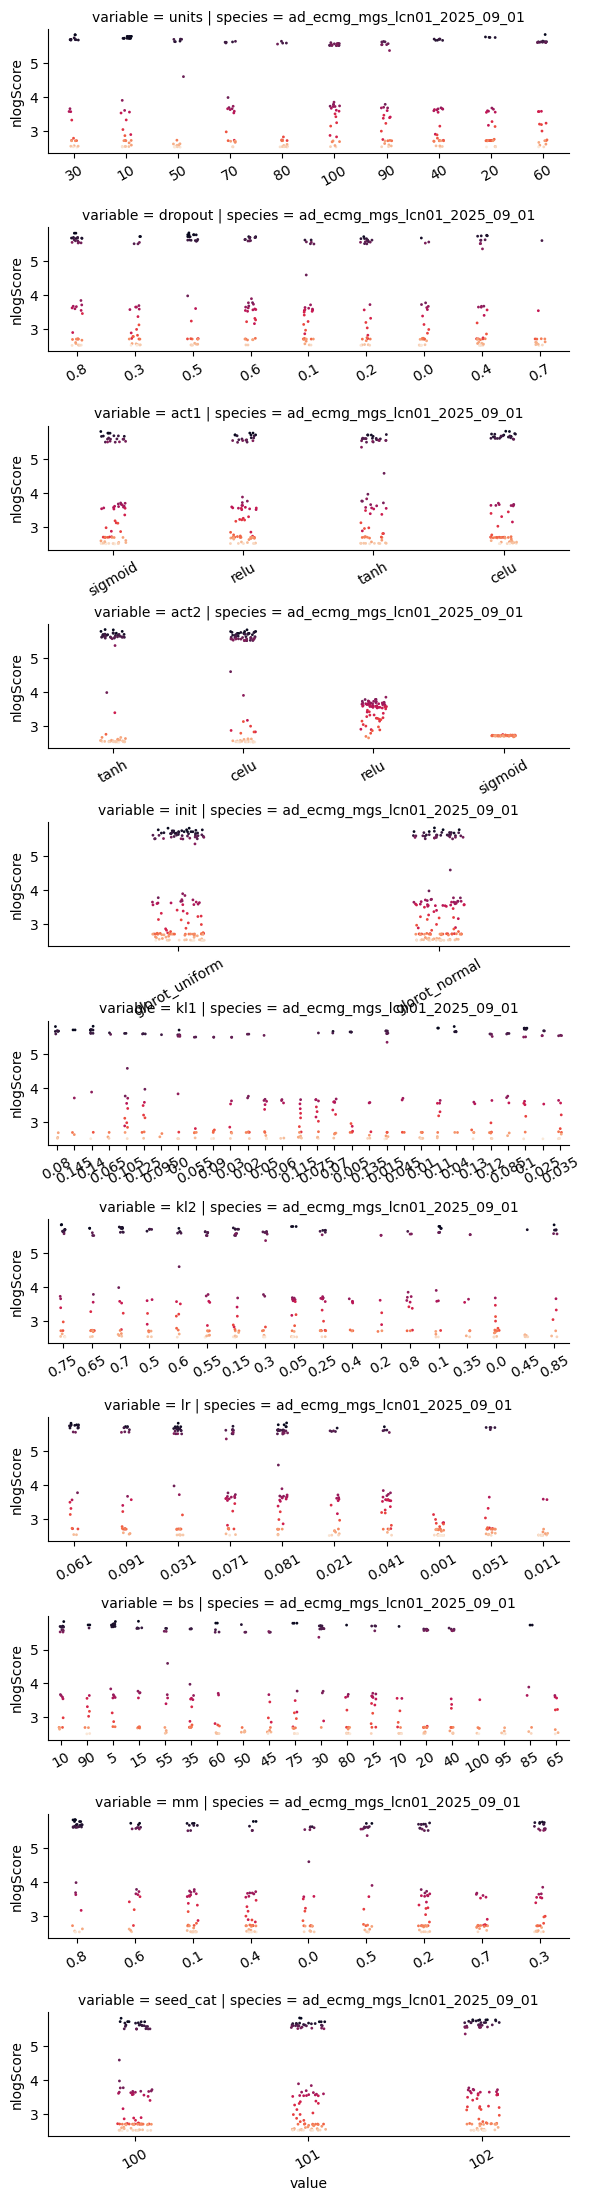

In [17]:
tuners_long = pd.melt(tuners_df.round(3),
                     id_vars=["Score","tuner/trial_id","Trial ID", 
                              "tuner_key","nlogScore","rank", "species","seed",
                             "shuffle","tied","tied_bool","tuner/epochs",
                             "tuner/round","tuner/initial_epoch","tuner/bracket",
                             "Best step"])

g = sns.catplot(data=tuners_long, 
    kind="strip", 
    col="species", 
    row='variable',
    x="value", 
    y="nlogScore",
    hue = "rank",palette = "rocket", 
                sharey = False, sharex=False,
                height=2, aspect=3,size = 2,
                legend=False
               )
g.fig.subplots_adjust(hspace=.6)
g.set_xticklabels(rotation=30)

## 4. Train models

In a previous hyperparameter seach I landed on the following:

* enccoding dimension: 450
* L1 normalizaion: 0
* L2 normalization: 0
* activation functios: tanh
* tied: True
* epochs: 100
* initialization: glorot_uniform
* batch_size: 15
* dropout: 0
* momentum: 0.6
* learning rate: 0.5

In [18]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv","ecmgp_lcn01.csv"]
model_dict_post = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/ecmg_mgs_lcn01.csv',
                                                  seed=seed+100,
                                                  enc_dim = 450,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=15,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5) 
        mseq = sa.train_model()
        sa.save_weights('/work/gd134/sA_out',name)
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_ecmg_mgs_lcn01_2025_09_01_100
Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0248 - val_loss: 0.0124
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0121 - val_loss: 0.0123
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0120 - val_loss: 0.0123
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0119 - val_loss: 0.0122
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0118 - val_loss: 0.0121
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 9/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0116 - val_loss: 0.0120
Epoch 10/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - val_loss: 0.0119
Epoch 11/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - val_loss: 0.0119
Epoch 12

In [19]:
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

769.3123104572296
6
128.2177621126175
12.821871840953827


## 5. Plot training loss

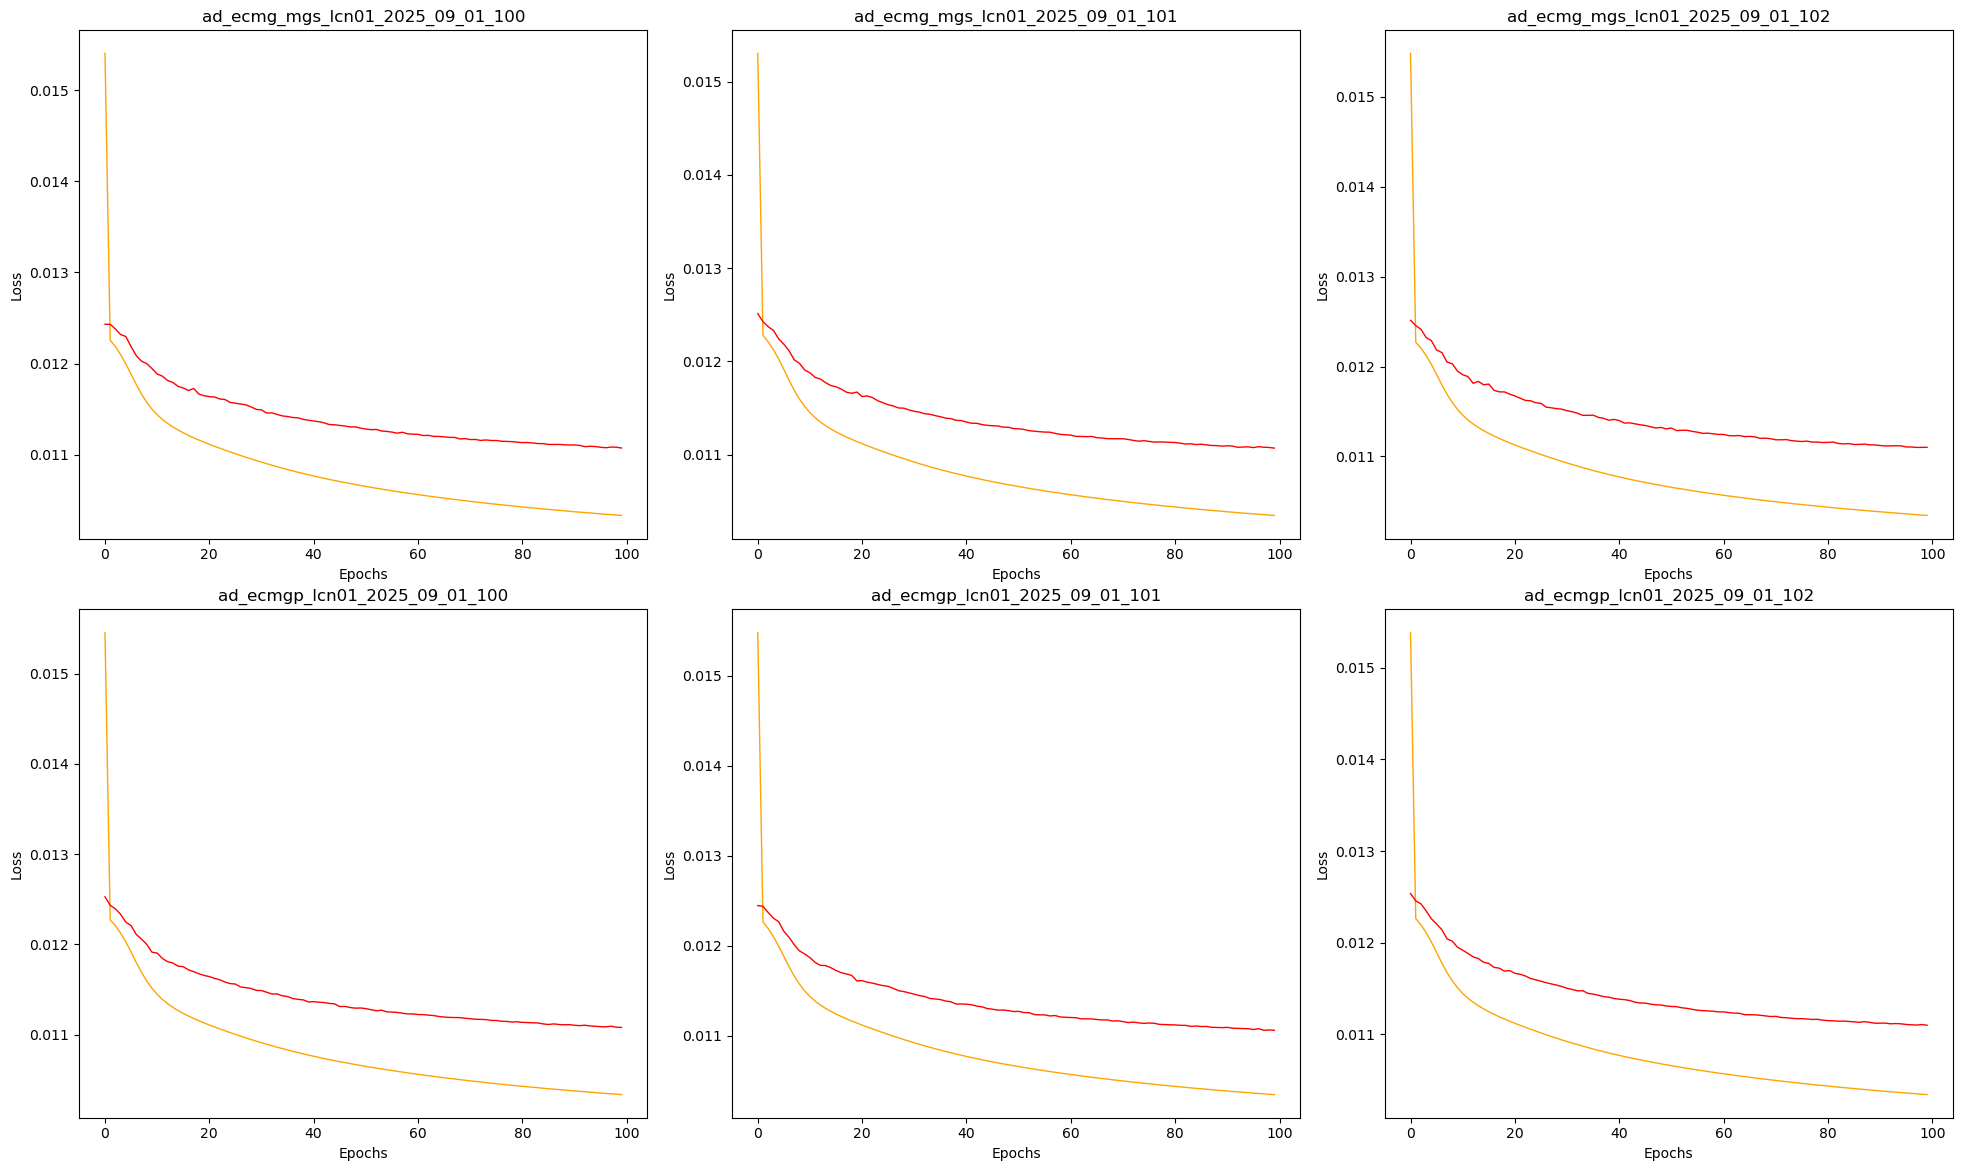

In [20]:
# set layout for panels of compendia and seeds
xd = len(comps) 
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1

## 6. Plot weight distributions

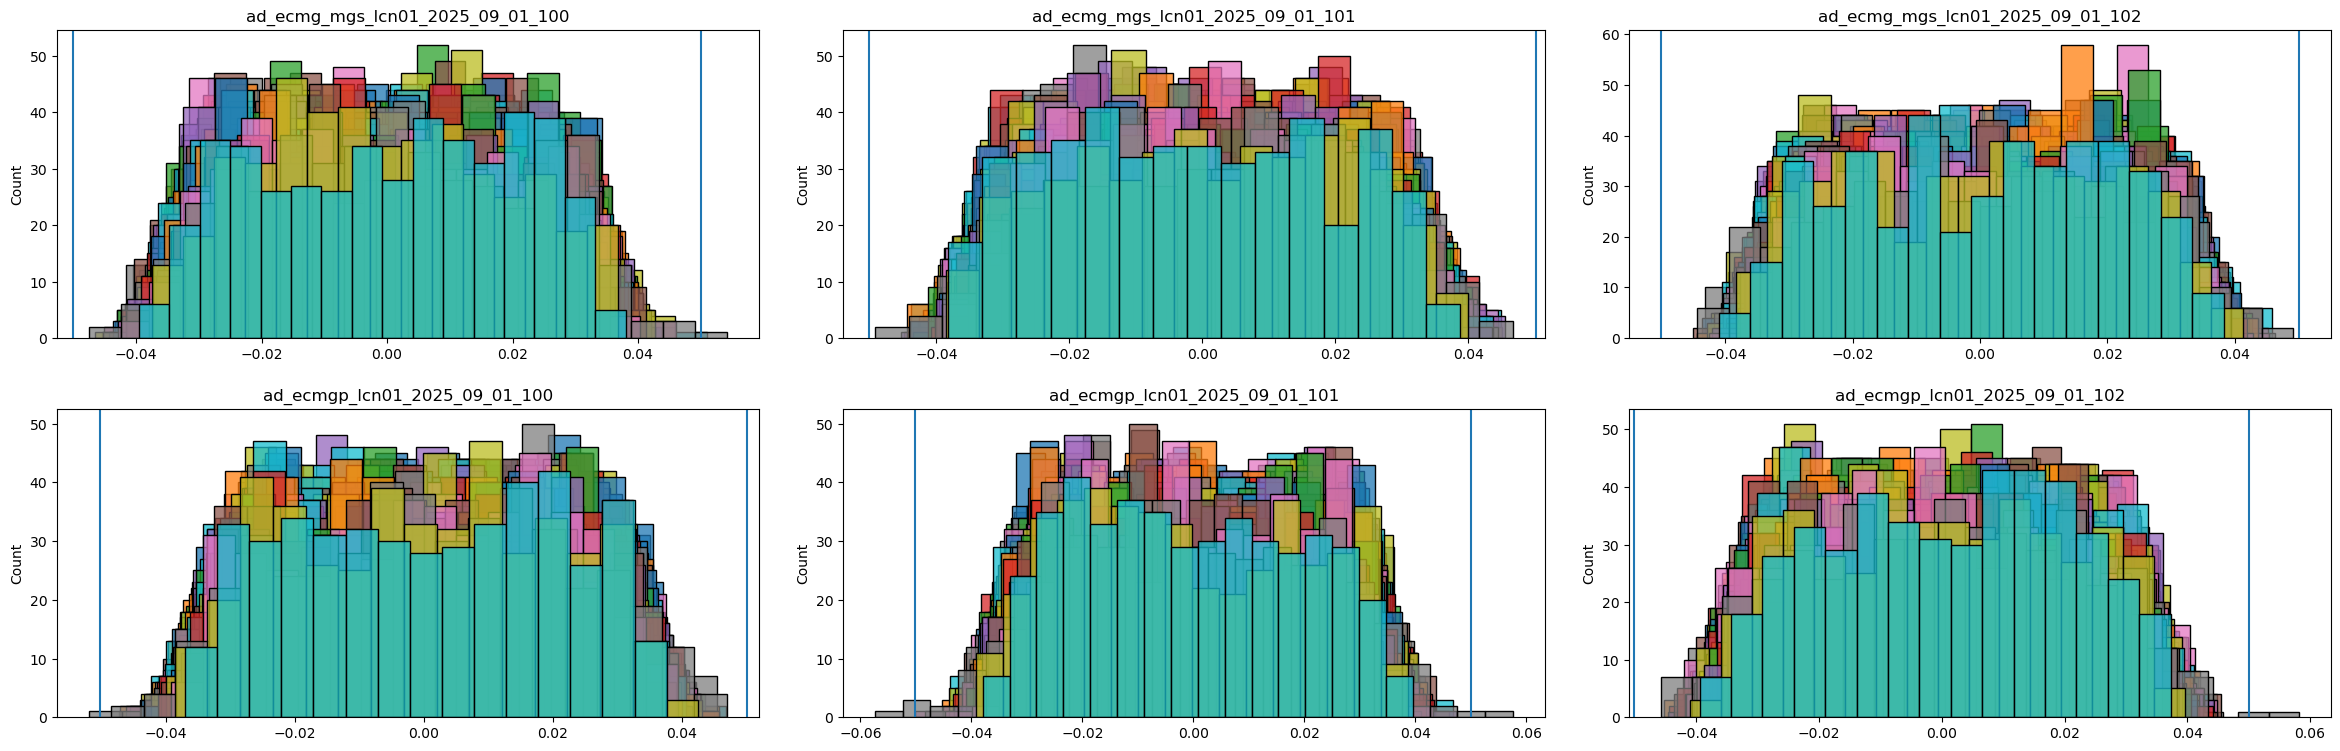

In [21]:
# set layout for panels of compendia and seeds
xd = len(comps) 
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1